# Dijkstra's Algorithm: Shortest Paths on Weighted Graphs

Given a directed or undirected graph $G = (V, E)$ with non-negative edge weights $w : E \to \mathbb{R}_{\geq 0}$, **Dijkstra's algorithm** (Edsger W. Dijkstra, 1959) computes the shortest-path distance from a source vertex $s$ to all other vertices in $V$.

**Core idea — greedy relaxation.** The algorithm maintains a set $S$ of vertices whose shortest distances are finalized and a priority queue $Q$ of candidates. At each step it:
1. Extracts the vertex $u \notin S$ with minimum tentative distance $d(u)$.
2. Marks $u$ as finalized: $S \leftarrow S \cup \{u\}$.
3. **Relaxes** every outgoing edge $(u, v)$: if $d(u) + w(u,v) < d(v)$, updates $d(v)$ and records the predecessor $\pi(v) = u$.

**Correctness** relies on the non-negativity of weights: once a vertex is extracted from $Q$, no shorter path to it can be found later (Dijkstra's cut property).

**Complexity** with a binary heap: $O((|V| + |E|)\log|V|)$. With a Fibonacci heap: $O(|E| + |V|\log|V|)$.

Dijkstra's algorithm is the foundation of routing protocols (OSPF, IS-IS), navigation systems, and is closely related to **fast marching methods** for continuous eikonal equations:
$$
|\nabla u(x)| = \frac{1}{c(x)}, \qquad u(s) = 0,
$$
where $c(x)$ is the local propagation speed and $u(x)$ is the travel time from source $s$.

This notebook implements Dijkstra from scratch, visualizes the wavefront expansion on 2D grid graphs, and compares different weight (cost) landscapes.

## Environment

In [1]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ipywidgets import interact, IntSlider

plt.rcParams["figure.dpi"] = 120

## Dijkstra implementation

We implement the algorithm on a generic sparse graph represented as an adjacency list. Python's `heapq` module provides the min-priority queue. The function returns both the distance array $d$ and the predecessor map $\pi$, from which shortest paths can be reconstructed.

In [2]:
def dijkstra(adj, source, target=None):
    """Dijkstra's algorithm on adj (list of lists of (neighbor, weight)).
    Returns (dist, prev) arrays."""
    n = len(adj)
    dist = np.full(n, np.inf)
    prev = np.full(n, -1, dtype=int)
    dist[source] = 0.0
    heap = [(0.0, source)]
    visited = np.zeros(n, dtype=bool)

    while heap:
        d_u, u = heapq.heappop(heap)
        if visited[u]:
            continue
        visited[u] = True
        if target is not None and u == target:
            break
        for v, w in adj[u]:
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u
                heapq.heappush(heap, (alt, v))
    return dist, prev


def reconstruct_path(prev, target):
    """Reconstruct shortest path from prev array."""
    path = []
    u = target
    while u != -1:
        path.append(u)
        u = prev[u]
    return path[::-1]


print("Dijkstra ready.")

Dijkstra ready.


## 2D grid graph

A 2D grid of size $n \times n$ can be viewed as a graph where each pixel $(i,j)$ connects to its 4 (or 8) neighbors. The edge weight $w((i,j),(i',j')) = \frac{c(i,j)+c(i',j')}{2}$ is the average cost between the two cells. A **cost map** $c : [0,1]^2 \to \mathbb{R}_{>0}$ encodes local traversal difficulty: high-cost regions act as obstacles that the shortest path avoids.

In [3]:
def grid_to_graph(cost, connectivity=4):
    """Build adjacency list from 2D cost map.
    Node index: i*n + j for grid of size n x n."""
    n = cost.shape[0]
    adj = [[] for _ in range(n * n)]

    if connectivity == 4:
        nbrs = [(-1,0),(1,0),(0,-1),(0,1)]
    else:  # 8-connectivity
        nbrs = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    for i in range(n):
        for j in range(n):
            u = i * n + j
            for di, dj in nbrs:
                ni, nj = i + di, j + dj
                if 0 <= ni < n and 0 <= nj < n:
                    v = ni * n + nj
                    w = 0.5 * (cost[i, j] + cost[ni, nj])
                    adj[u].append((v, w))
    return adj


def run_grid_dijkstra(cost, src_ij, tgt_ij):
    n = cost.shape[0]
    adj = grid_to_graph(cost)
    src = src_ij[0] * n + src_ij[1]
    tgt = tgt_ij[0] * n + tgt_ij[1]
    dist, prev = dijkstra(adj, src, tgt)
    dist_map = dist.reshape(n, n)
    path_nodes = reconstruct_path(prev, tgt)
    path_ij = [(v // n, v % n) for v in path_nodes]
    return dist_map, path_ij


print("Grid graph builder ready.")

Grid graph builder ready.


## Uniform cost: isotropic wavefront

On a uniform cost map ($c \equiv 1$), Dijkstra's expanding wavefront is exactly a discrete circle: the distance map $d(i,j)$ approximates the Euclidean distance from the source. This verifies correctness and makes the discrete-to-continuous connection transparent.

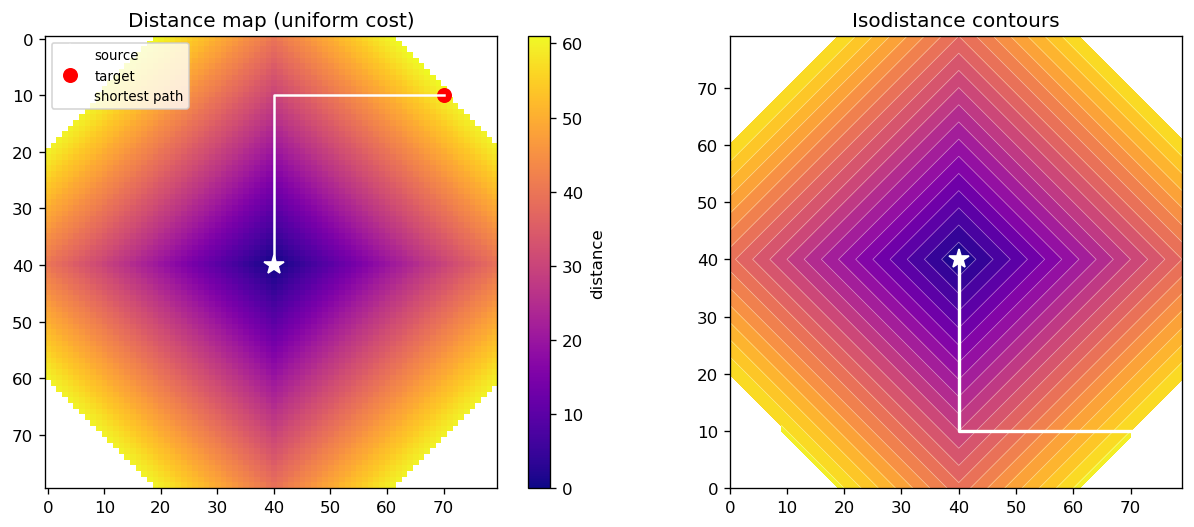

In [4]:
n_grid = 80
cost_uniform = np.ones((n_grid, n_grid))
src = (n_grid // 2, n_grid // 2)
tgt = (10, 70)

dist_map, path = run_grid_dijkstra(cost_uniform, src, tgt)
path_arr = np.array(path)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im = axes[0].imshow(dist_map, origin="upper", cmap="plasma",
                    interpolation="nearest")
axes[0].plot(*src[::-1], "w*", ms=12, label="source")
axes[0].plot(*tgt[::-1], "ro", ms=8, label="target")
axes[0].plot(path_arr[:,1], path_arr[:,0], "w-", lw=1.5, label="shortest path")
plt.colorbar(im, ax=axes[0], label="distance")
axes[0].set_title("Distance map (uniform cost)")
axes[0].legend(fontsize=8)

# contour plot
axes[1].contourf(dist_map, levels=20, cmap="plasma")
axes[1].contour(dist_map, levels=20, colors="w", linewidths=0.4, alpha=0.5)
axes[1].plot(*src[::-1], "w*", ms=12)
axes[1].plot(path_arr[:,1], path_arr[:,0], "w-", lw=2)
axes[1].set_title("Isodistance contours")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## Heterogeneous cost landscape: shortest path avoids obstacles

We build a cost map with high-cost "walls" (mountains) and low-cost corridors (valleys). Dijkstra automatically routes the path through the easiest terrain — mimicking GPS navigation, robot path planning, or seismic ray tracing.

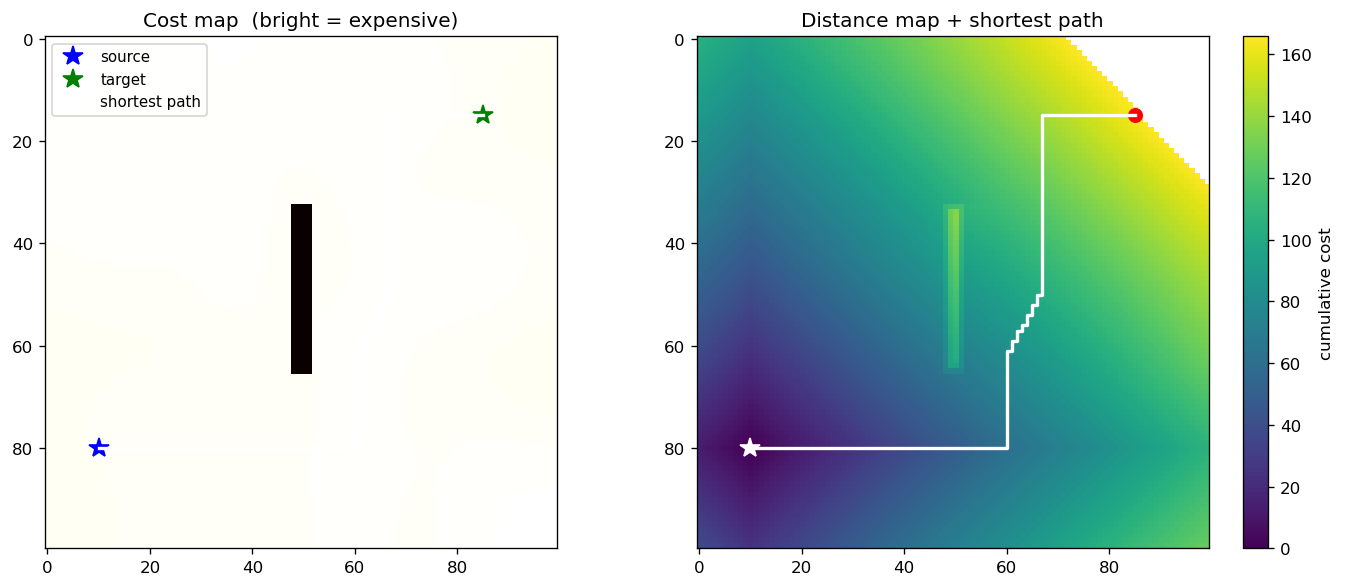

In [5]:
def make_terrain(n, seed=5):
    rng = np.random.default_rng(seed)
    # smooth random cost via Gaussian blur approximation
    raw = rng.random((n, n))
    # simple box blur for smoothing
    from scipy.ndimage import gaussian_filter
    smooth = gaussian_filter(raw, sigma=n / 12)
    cost = 0.2 + 4.0 * smooth**2
    # add a "wall"
    cost[n//3:2*n//3, n//2-2:n//2+2] = 20.0
    return cost


n_t = 100
cost_terrain = make_terrain(n_t)
src_t = (80, 10)
tgt_t = (15, 85)

dist_t, path_t = run_grid_dijkstra(cost_terrain, src_t, tgt_t)
path_t_arr = np.array(path_t)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cost_terrain, origin="upper", cmap="hot_r",
               interpolation="nearest")
axes[0].plot(*src_t[::-1], "b*", ms=12, label="source")
axes[0].plot(*tgt_t[::-1], "g*", ms=12, label="target")
axes[0].plot(path_t_arr[:,1], path_t_arr[:,0], "w-", lw=2, label="shortest path")
axes[0].set_title("Cost map  (bright = expensive)")
axes[0].legend(fontsize=9)

finite = np.where(np.isfinite(dist_t), dist_t, np.nan)
im2 = axes[1].imshow(finite, origin="upper", cmap="viridis",
                     interpolation="nearest")
axes[1].plot(*src_t[::-1], "w*", ms=12)
axes[1].plot(*tgt_t[::-1], "ro", ms=8)
axes[1].plot(path_t_arr[:,1], path_t_arr[:,0], "w-", lw=2)
plt.colorbar(im2, ax=axes[1], label="cumulative cost")
axes[1].set_title("Distance map + shortest path")

plt.tight_layout()
plt.show()

## Wavefront expansion snapshots

We replay the wavefront by sorting nodes by their final distance and revealing them progressively. Each snapshot shows the set of nodes with $d(v) \leq d_{\max}^{(k)}$ at step $k$, illustrating how the algorithm greedily expands the explored region from the source.

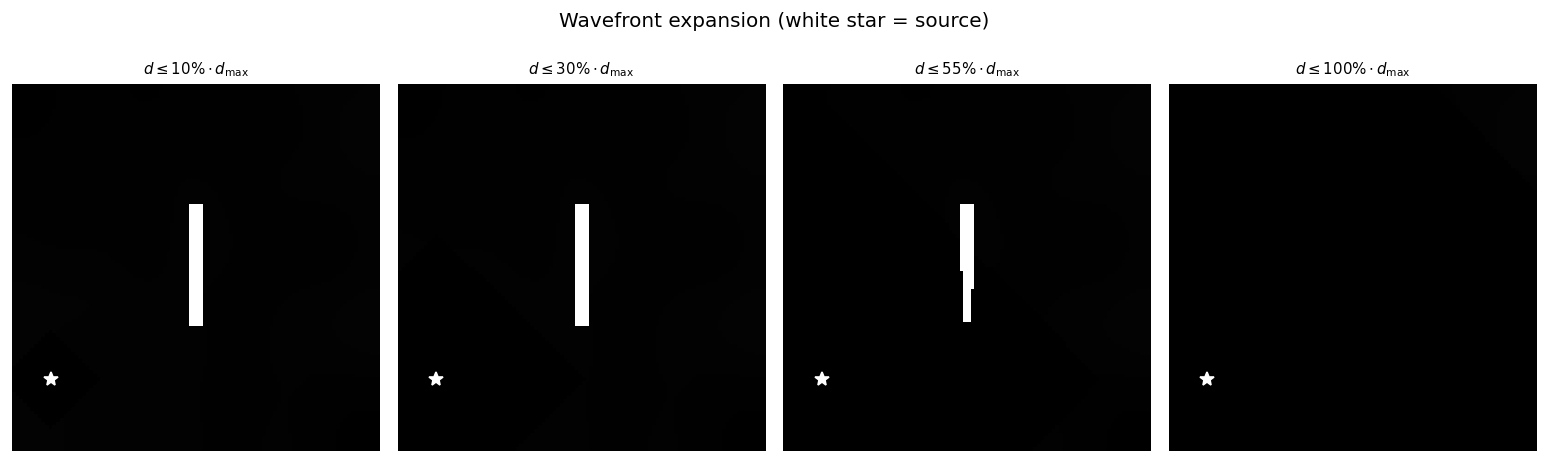

In [6]:
show_steps = [0.1, 0.3, 0.55, 1.0]
d_max = np.nanmax(finite)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
for ax, frac in zip(axes, show_steps):
    mask = finite <= frac * d_max
    overlay = np.full((n_t, n_t, 3), 0.95)
    # cost background
    cn = (cost_terrain - cost_terrain.min()) / (cost_terrain.max() - cost_terrain.min())
    overlay[:, :, 0] = cn
    overlay[:, :, 1] = cn
    overlay[:, :, 2] = cn
    # visited region: color by distance
    dn = (finite - finite.min()) / (d_max - finite.min() + 1e-8)
    overlay[mask, 0] = plt.cm.plasma(dn[mask])[:, 0]
    overlay[mask, 1] = plt.cm.plasma(dn[mask])[:, 1]
    overlay[mask, 2] = plt.cm.plasma(dn[mask])[:, 2]
    ax.imshow(np.clip(overlay, 0, 1), origin="upper", interpolation="nearest")
    ax.plot(*src_t[::-1], "w*", ms=9)
    ax.set_title(f"$d \\leq {100*frac:.0f}\\% \\cdot d_{{\\max}}$", fontsize=9)
    ax.axis("off")
fig.suptitle("Wavefront expansion (white star = source)", y=1.02)
plt.tight_layout()
plt.show()

## Interactive: move the source

Recompute the distance map from any source position on the terrain.

In [7]:
def show_source(row=80, col=10):
    d_src, _ = run_grid_dijkstra(cost_terrain, (row, col), (0, 0))
    fin = np.where(np.isfinite(d_src), d_src, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].imshow(cost_terrain, origin="upper", cmap="hot_r",
                   interpolation="nearest")
    axes[0].plot(col, row, "b*", ms=14)
    axes[0].set_title("Cost landscape")

    im = axes[1].imshow(fin, origin="upper", cmap="viridis",
                        interpolation="nearest")
    axes[1].plot(col, row, "w*", ms=14)
    axes[1].contour(fin, levels=12, colors="w", linewidths=0.5, alpha=0.4)
    plt.colorbar(im, ax=axes[1], label="distance")
    axes[1].set_title(f"Distance from source ({row}, {col})")
    plt.tight_layout(); plt.show()

interact(
    show_source,
    row=IntSlider(value=80, min=0, max=n_t-1, step=5, description="row"),
    col=IntSlider(value=10, min=0, max=n_t-1, step=5, description="col"),
);

interactive(children=(IntSlider(value=80, description='row', max=99, step=5), IntSlider(value=10, description=…

## Bibliographical resources

- Dijkstra, E. W. (1959). A note on two problems in connexion with graphs. *Numerische Mathematik*, 1(1), 269–271.
- Cormen, T. H., Leiserson, C. E., Rivest, R. L., and Stein, C. (2009). *Introduction to Algorithms* (3rd ed.). MIT Press.
- Fredman, M. L. and Tarjan, R. E. (1987). Fibonacci heaps and their uses in improved network optimization algorithms. *Journal of the ACM*, 34(3), 596–615.
- Sethian, J. A. (1999). *Level Set Methods and Fast Marching Methods*. Cambridge University Press. (Continuous analogue via the eikonal equation.)
- Hart, P. E., Nilsson, N. J., and Raphael, B. (1968). A formal basis for heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics*, 4(2), 100–107. (A* algorithm.)